In [57]:
import numpy as np
import matplotlib.pyplot as plt


In [49]:
# Configuration for a Main-Sequence star (similar to 16 Cyg B)
# Based on PSLS Version 1.9 configuration standards
psls_config = {
    "Observation": {
        "Duration": 730.0,       # Duration in days (2 years)
        "MasterSeed": 17040409   # For reproducibility
    },
    "Instrument": {
        "Sampling": 25.0,        # PLATO sampling period in seconds
        "RandomNoise": {
            "Enable": 1,
            "NSR": 73.0          # Noise-to-Signal Ratio in ppm
        },
        "Systematics": {"Enable": 1} # Include instrumental systematic errors
    },
    "Star": {
        "Mag": 10.0,             # Apparent magnitude
        "Teff": 5750.0,          # Effective temperature in Kelvin
        "Logg": 4.353,           # Surface gravity
        "ES": "ms"               # Evolutionary Status: Main-Sequence
    },
    "Activity": {
        "Enable": 1,
        "Sigma": 40.0,           # Activity amplitude in ppm
        "Tau": 0.2               # Characteristic timescale in days
    },
    "Granulation": {"Enable": 1}, # Stellar granulation background
    "Oscillations": {"Enable": 1},# Stochastically-excited oscillations
    "Flares": {                  # Flare injection (Available in PSLS v1.9)
        "Enable": 1,
        "Prescription": "Baudin"
    }
}


In [50]:
psls_config["Transit"] = {
    "Enable": 0,
    "PlanetRadius": 0.5,         # Radius in Jupiter radii
    "OrbitalPeriod": 10.0,       # Orbital period in days
    "PlanetSemiMajorAxis": 1.0,  # In A.U.
    "OrbitalAngle": 0.0,         # Inclination angle in degrees
    "LimbDarkeningCoefficients": [0.25, 0.75] #
}

In [53]:
# Generate the light curve using PSLS
light_curve = simulate(psls_config)


NameError: name 'simulate' is not defined

In [51]:
#plot
plt.figure(figsize=(12, 6))
plt.plot(light_curve["time"], light_curve["flux"], color='blue', label='Simulated Light Curve')
plt.xlabel('Time (days)')
plt.ylabel('Relative Flux')
plt.title('Simulated PLATO Light Curve with Stellar Activity and Oscillations')
plt.legend()
plt.grid()
plt.show()

NameError: name 'light_curve' is not defined

<Figure size 1200x600 with 0 Axes>

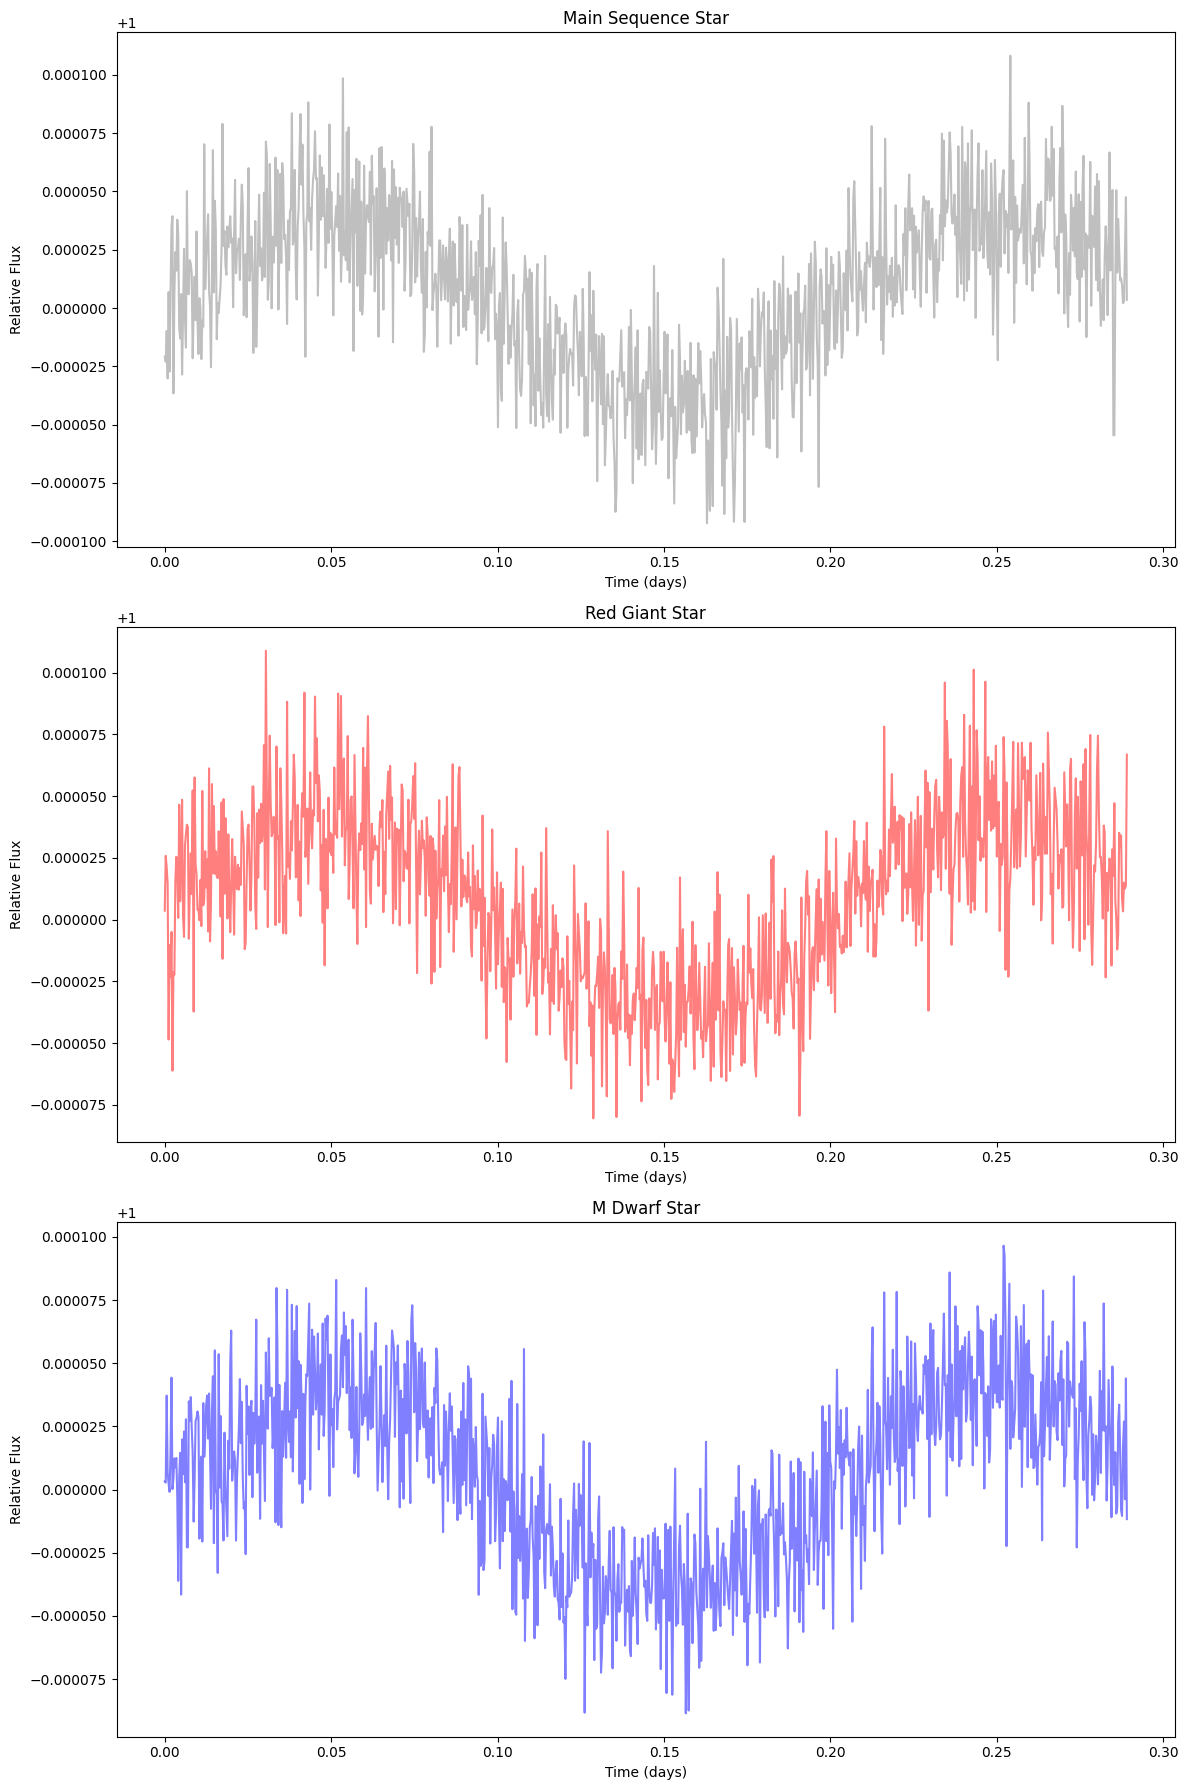

In [25]:
#now let us plot side by side light curves for main sequence, red giants and M dwarves

# Configuration for a Red Giant star
psls_config_red_giant = psls_config.copy()
psls_config_red_giant["Star"]["Teff"] = 4500.0
psls_config_red_giant["Star"]["Logg"] = 2.5
psls_config_red_giant["Star"]["ES"] = "rg"  # Red Giant

# Configuration for an M Dwarf star
psls_config_m_dwarf = psls_config.copy()
psls_config_m_dwarf["Star"]["Teff"] = 3500.0
psls_config_m_dwarf["Star"]["Logg"] = 4.8
psls_config_m_dwarf["Star"]["ES"] = "md"  # M Dwarf

# Generate data for all three types of stars
time_ms, flux_ms = run_plato_simulation(psls_config)           # Main Sequence
time_rg, flux_rg = run_plato_simulation(psls_config_red_giant) # Red Giant
time_md, flux_md = run_plato_simulation(psls_config_m_dwarf)    # M Dwarf
# Plotting side by side
fig, axs = plt.subplots(3, 1, figsize=(12, 18))
axs[0].plot(time_ms[:1000], flux_ms[:1000], color='grey', alpha=0.5)
axs[0].set_title("Main Sequence Star")
axs[0].set_xlabel("Time (days)")
axs[0].set_ylabel("Relative Flux") 
axs[1].plot(time_rg[:1000], flux_rg[:1000], color='red', alpha=0.5)
axs[1].set_title("Red Giant Star")
axs[1].set_xlabel("Time (days)")
axs[1].set_ylabel("Relative Flux")
axs[2].plot(time_md[:1000], flux_md[:1000], color='blue', alpha=0.5)
axs[2].set_title("M Dwarf Star")
axs[2].set_xlabel("Time (days)")
axs[2].set_ylabel("Relative Flux")
plt.tight_layout()
plt.show()